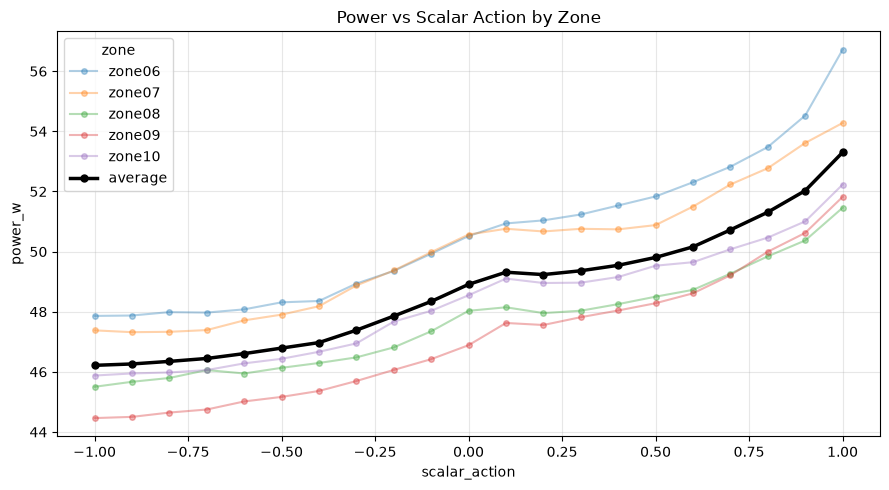


Mean power_w per scalar_action:
scalar_action
-1.0    46.217333
-0.9    46.263000
-0.8    46.348600
-0.7    46.445933
-0.6    46.607267
-0.5    46.790733
-0.4    46.973933
-0.3    47.386800
-0.2    47.855933
-0.1    48.342933
 0.0    48.910533
 0.1    49.314800
 0.2    49.235733
 0.3    49.362667
 0.4    49.544933
 0.5    49.806533
 0.6    50.158667
 0.7    50.722200
 0.8    51.311333
 0.9    52.027600
 1.0    53.299800


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('blue2red_power.csv')

fig, ax = plt.subplots(figsize=(9, 5))

for zone, group in df.groupby('zone'):
    label = zone.replace('alliance-', '')
    group = group.sort_values('scalar_action')
    ax.plot(group['scalar_action'], group['power_w'], marker='o', markersize=4, label=label, alpha=0.35)

avg = df.groupby('scalar_action')['power_w'].mean().sort_index()
ax.plot(avg.index, avg.values, marker='o', markersize=5, linewidth=2.5, color='black', label='average')

ax.set_xlabel('scalar_action')
ax.set_ylabel('power_w')
ax.set_title('Power vs Scalar Action by Zone')
ax.legend(title='zone')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nMean power_w per scalar_action:')
print(avg.to_string())

In [2]:
import json

config = {
    "blue2red_power": {
        "scalar_action": avg.index.tolist(),
        "power_w": avg.values.tolist(),
    }
}

output_path = 'blue2red_power_config.json'
with open(output_path, 'w') as f:
    json.dump(config, f, indent=2)

print(json.dumps(config, indent=2))
print(f'\nSaved to {output_path}')

{
  "blue2red_power": {
    "scalar_action": [
      -1.0,
      -0.9,
      -0.8,
      -0.7,
      -0.6,
      -0.5,
      -0.4,
      -0.3,
      -0.2,
      -0.1,
      0.0,
      0.1,
      0.2,
      0.3,
      0.4,
      0.5,
      0.6,
      0.7,
      0.8,
      0.9,
      1.0
    ],
    "power_w": [
      46.217333333333336,
      46.263,
      46.3486,
      46.445933333333336,
      46.60726666666667,
      46.790733333333336,
      46.973933333333335,
      47.3868,
      47.85593333333334,
      48.342933333333335,
      48.91053333333333,
      49.314800000000005,
      49.23573333333333,
      49.36266666666667,
      49.54493333333333,
      49.806533333333334,
      50.15866666666666,
      50.7222,
      51.31133333333334,
      52.02760000000001,
      53.299800000000005
    ]
  }
}

Saved to blue2red_power_config.json
